In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

In [11]:
data = pd.read_csv("../data/processed/cleaned_news.csv")

# Handle missing text values
data["clean_content"] = data["clean_content"].fillna("")

# Make sure all text values are strings
data["clean_content"] = data["clean_content"].astype(str)

print("Missing values:", data["clean_content"].isnull().sum())
print("Dataset shape:", data.shape)

Missing values: 0
Dataset shape: (44689, 2)


In [12]:
data.head()

,clean_content,label
0,donald trump sends embarrassing new year’s eve...,0
1,drunk bragging trump staffer started russian c...,0
2,sheriff david clarke becomes internet joke thr...,0
3,trump obsessed even obama’s name coded website...,0
4,pope francis called donald trump christmas spe...,0


In [13]:
print(data["label"].value_counts())

label
0    23478
1    21211
Name: count, dtype: int64


In [14]:
X = data["clean_content"]
y = data["label"]

In [15]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 35751
Testing samples: 8938



What is Bag of Words?

Suppose we have:

Document 1: "dog likes food"

Document 2: "dog eats food"

Vocabulary:

dog
likes
food
eats

BoW converts the documents into numbers:

             dog  likes  food  eats

Document 1    1     1     1     0

Document 2    1     0     1     1

The model can now work with numerical features.

In [16]:
# Create BoW vectorizer
bow_vectorizer = CountVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    stop_words="english"
)

In [27]:
# Fit BoW on training data
X_train_bow = bow_vectorizer.fit_transform(X_train)

# Transform test data using the same vocabulary
X_test_bow = bow_vectorizer.transform(X_test)

In [ ]:
# Check BoW
print("BoW training shape:", X_train_bow.shape)
print("BoW testing shape:", X_test_bow.shape)

BoW training shape: (35751, 10000)
BoW testing shape: (8938, 10000)


In [29]:
# See the vocabulary
feature_names = bow_vectorizer.get_feature_names_out()

print(feature_names[:50])

['aaron' 'abadi' 'abandon' 'abandoned' 'abandoning' 'abbas' 'abbott' 'abc'
 'abc news' 'abc week' 'abdel' 'abdullah' 'abe' 'abedin' 'abide' 'ability'
 'able' 'aboard' 'abortion' 'abortions' 'abroad' 'abruptly' 'absence'
 'absent' 'absolute' 'absolutely' 'absurd' 'abu' 'abuse' 'abused' 'abuses'
 'abusive' 'aca' 'academic' 'academics' 'academy' 'accept' 'acceptable'
 'acceptance' 'accepted' 'accepting' 'access' 'accident' 'accidentally'
 'accompanied' 'accomplish' 'accomplished' 'accomplishments' 'accord'
 'accordance']


In [30]:
# See an actual BoW vector
print(X_train_bow[0].toarray())

[[0 0 0 ... 0 0 0]]


TF-IDF

Now we implement the second major feature extraction technique required by your assignment.

What is TF-IDF?

TF-IDF stands for:

Term Frequency — Inverse Document Frequency

The basic idea:

A word gets a high weight if it is important in a particular document but isn't common across the entire dataset.

For example, words like:

the
is
and

appear everywhere and usually carry less distinguishing information.

A more specific word may receive a higher TF-IDF value.

In [31]:
# Create TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    stop_words="english",
    sublinear_tf=True
)

In [33]:
# Fit TF-IDF
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [34]:
# Check TF-IDF dimensions
print("TF-IDF training shape:", X_train_tfidf.shape)
print("TF-IDF testing shape:", X_test_tfidf.shape)

TF-IDF training shape: (35751, 10000)
TF-IDF testing shape: (8938, 10000)


In [35]:
# Look at TF-IDF vocabulary
tfidf_features = tfidf_vectorizer.get_feature_names_out()

print(tfidf_features[:50])

['aaron' 'abadi' 'abandon' 'abandoned' 'abandoning' 'abbas' 'abbott' 'abc'
 'abc news' 'abc week' 'abdel' 'abdullah' 'abe' 'abedin' 'abide' 'ability'
 'able' 'aboard' 'abortion' 'abortions' 'abroad' 'abruptly' 'absence'
 'absent' 'absolute' 'absolutely' 'absurd' 'abu' 'abuse' 'abused' 'abuses'
 'abusive' 'aca' 'academic' 'academics' 'academy' 'accept' 'acceptable'
 'acceptance' 'accepted' 'accepting' 'access' 'accident' 'accidentally'
 'accompanied' 'accomplish' 'accomplished' 'accomplishments' 'accord'
 'accordance']


In [36]:
# See TF-IDF values
print(X_train_tfidf[0].toarray())

[[0. 0. 0. ... 0. 0. 0.]]


In [37]:
# Compare BoW and TF-IDF
print("BoW features:", X_train_bow.shape[1])
print("TF-IDF features:", X_train_tfidf.shape[1])

BoW features: 10000
TF-IDF features: 10000


In [39]:
#Find important TF-IDF words
import numpy as np

feature_names = tfidf_vectorizer.get_feature_names_out()

mean_scores = np.asarray(
    X_train_tfidf.mean(axis=0)
).ravel()

top_indices = mean_scores.argsort()[-20:][::-1]

top_words = feature_names[top_indices]
top_scores = mean_scores[top_indices]

for word, score in zip(top_words, top_scores):
    print(f"{word}: {score:.4f}")

trump: 0.0327
said: 0.0294
president: 0.0205
people: 0.0173
reuters: 0.0161
video: 0.0160
donald: 0.0153
state: 0.0149
house: 0.0149
new: 0.0148
donald trump: 0.0148
obama: 0.0146
clinton: 0.0134
republican: 0.0132
government: 0.0132
white: 0.0132
told: 0.0131
states: 0.0130
like: 0.0127
hillary: 0.0125


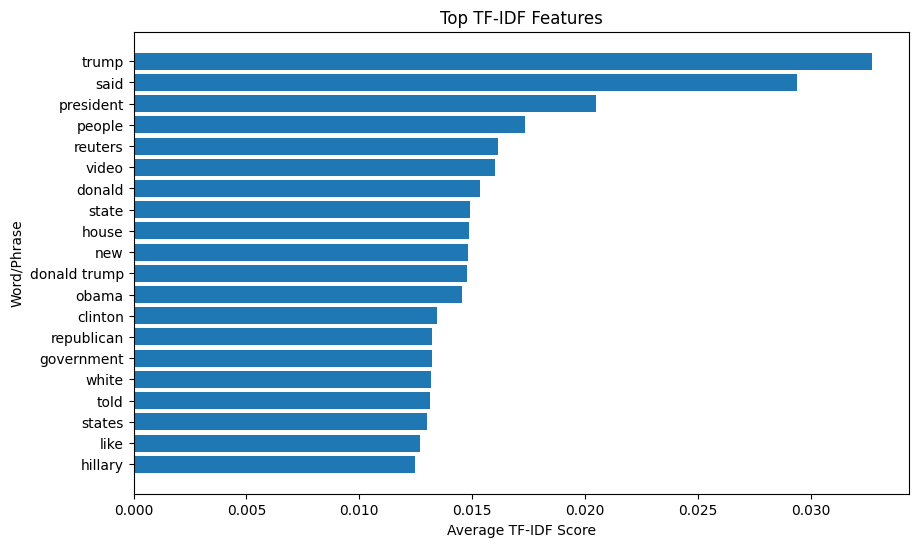

In [40]:
# Visualize important words
plt.figure(figsize=(10, 6))

plt.barh(
    top_words[::-1],
    top_scores[::-1]
)

plt.title("Top TF-IDF Features")
plt.xlabel("Average TF-IDF Score")
plt.ylabel("Word/Phrase")

plt.show()

In [41]:
# Save feature matrices
from scipy.sparse import save_npz

save_npz(
    "../data/processed/X_train_bow.npz",
    X_train_bow
)

save_npz(
    "../data/processed/X_test_bow.npz",
    X_test_bow
)

save_npz(
    "../data/processed/X_train_tfidf.npz",
    X_train_tfidf
)

save_npz(
    "../data/processed/X_test_tfidf.npz",
    X_test_tfidf
)

print("Feature matrices saved successfully.")

Feature matrices saved successfully.


In [42]:
# Save labels
y_train.to_csv(
    "../data/processed/y_train.csv",
    index=False
)

y_test.to_csv(
    "../data/processed/y_test.csv",
    index=False
)

print("Labels saved successfully.")

Labels saved successfully.


In [43]:
# Save vectorizers
import joblib

In [44]:
joblib.dump(
    bow_vectorizer,
    "../data/processed/bow_vectorizer.pkl"
)

joblib.dump(
    tfidf_vectorizer,
    "../data/processed/tfidf_vectorizer.pkl"
)

print("Vectorizers saved successfully.")

Vectorizers saved successfully.


1. What is an embedding?

An embedding converts text/words into numerical vectors so that a machine-learning model can work with them.

For example:

"government" → [0.21, -0.45, 0.73, 0.12, ...]

Instead of representing a word as just text, we represent it as a vector of numbers.

The important idea is:

Words with similar meanings tend to have similar vector representations.

For example, a trained embedding might represent:

government → [0.21, -0.45, 0.73, ...]
minister   → [0.19, -0.41, 0.70, ...]
banana     → [-0.82, 0.33, -0.14, ...]

The vectors for government and minister would generally be closer than government and banana.

2. Why do we need embeddings?

Our original news article is text:

"Government announces new economic policy"

A machine-learning algorithm cannot directly understand this sentence.

We need to convert it into numbers.

There are several ways:

Bag of Words
government → 1
announces  → 1
economic   → 1
policy     → 1

It mainly tells us whether/how often words occur.

TF-IDF

It gives importance to words:

government → 0.42
economic   → 0.71
policy     → 0.63

It considers how important a word is within the dataset.

Embeddings

It represents words using dense vectors that can capture relationships between words:

government → [0.21, -0.45, 0.73, ...]

So embeddings give us a different representation of text.

In [46]:
! pip install gensim

Defaulting to user installation because normal site-packages is not writeable
  Using cached gensim-4.4.0-cp313-cp313-win_amd64.whl.metadata (8.6 kB)
  Using cached smart_open-8.0.1-py3-none-any.whl.metadata (24 kB)
  Using cached wrapt-2.4.0-cp313-cp313-win_amd64.whl.metadata (7.6 kB)
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/24.4 MB ? eta -:--:--
    --------------------------------------- 0.5/24.4 MB 1.3 MB/s eta 0:00:20
   - -------------------------------------- 1.0/24.4 MB 1.6 MB/s eta 0:00:15
   -- ------------------------------------- 1.3/24.4 MB 1.4 MB/s eta 0:00:17
   --- ------------------------------------ 1.8/24.4 MB 1.7 MB

ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\Users\\rahul\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python313\\site-packages\\gensim\\models\\_fasttext_bin.py'
Check the permissions.


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\rahul\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
# Import Word2Vec
from gensim.models import Word2Vec
import numpy as np

In [48]:
# Tokenize the training and testing text
X_train_tokens = X_train.apply(lambda text: text.split())
X_test_tokens = X_test.apply(lambda text: text.split())

In [49]:
print(X_train_tokens.iloc[0][:20])

['trump', 'got', 'another', 'totally', 'real', 'letter', 'fake', 'kid', 'loves', 'one’s', 'buying', 'sarah', 'huckabee', 'sanders', 'decided', 'show', 'everyone', 'much', 'people', 'love']


In [50]:
# Train Word2Vec
word2vec_model = Word2Vec(
    sentences=X_train_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1,
    epochs=5,
    seed=42
)

In [51]:
# Check the vocabulary
print("Vocabulary size:", len(word2vec_model.wv))

Vocabulary size: 110146


In [52]:
print(word2vec_model.wv["government"])

[ 0.36357117 -0.49332032 -0.5606236  -0.13624808 -0.19185133  0.16382472
  0.12376641  0.09810045 -0.37287045 -0.3104812  -0.54783577  0.09803309
 -0.14104669 -0.02142974 -0.41962737 -0.18797755 -0.00353284 -0.5269072
 -0.08369965  0.22994542  0.22305712 -0.24522272 -0.32989255  0.38327056
  0.39493015 -0.58632684  0.10574639 -0.00462034 -0.238092   -0.01593121
 -0.1569142  -0.11127734  0.4629732   0.1014014   0.19333337 -0.21100526
  0.08602712 -0.8456294  -0.2547235   0.40021825  0.43244419 -0.22307104
  0.7410988  -0.15296234 -0.5493675  -0.09281946 -0.1596668   0.19456828
  0.68740225 -0.13947406 -0.1397805  -0.3419579   0.3662479  -0.07551545
 -0.03201051  0.18749875 -0.10939121  0.83376986 -0.01887877  0.58871704
  0.38991314  0.15958877 -0.50550944  0.00322176  0.22297992  0.2549937
  0.29251468  0.05369706 -0.19895019 -0.07992795 -0.10105118 -0.09794066
 -0.07481167 -0.04747819  0.19523887 -0.32873973  0.2673733   0.10358656
 -0.04212487  0.08742568 -0.36943036  0.11946397 -0.0

In [53]:
# Check similar words
word2vec_model.wv.most_similar("government", topn=10)

[('governments', 0.6804212927818298),
 ('micromanagement', 0.6766101717948914),
 ('attained', 0.6751130819320679),
 ('suffocating', 0.6738023161888123),
 ('noncooperation', 0.6725558042526245),
 ('decentralized', 0.6713619828224182),
 ('hamstrung', 0.6704156398773193),
 ('exerted', 0.6699026823043823),
 ('relinquish', 0.6683805584907532),
 ('councillors', 0.6669232845306396)]

In [54]:
# Convert each article into one vector
def document_vector(tokens, model):
    
    vectors = [
        model.wv[word]
        for word in tokens
        if word in model.wv
    ]
    
    if not vectors:
        return np.zeros(model.vector_size)
    
    return np.mean(vectors, axis=0)

In [55]:
# Generate training embeddings
X_train_w2v = np.vstack([
    document_vector(tokens, word2vec_model)
    for tokens in X_train_tokens
])

In [56]:
print("Word2Vec training shape:", X_train_w2v.shape)

Word2Vec training shape: (35751, 100)


In [57]:
# Generate testing embeddings
X_test_w2v = np.vstack([
    document_vector(tokens, word2vec_model)
    for tokens in X_test_tokens
])

In [58]:
print("Word2Vec testing shape:", X_test_w2v.shape)

Word2Vec testing shape: (8938, 100)


In [59]:
# Check the embeddings
print("First article embedding:")
print(X_train_w2v[0])

First article embedding:
[ 0.20768403 -0.14138031 -0.05245929 -0.00213563 -0.14812234  0.10253014
  0.21808521  0.2415234   0.07223109 -0.08285284 -0.25598019  0.16311142
  0.01511261  0.13841599  0.04786786 -0.20539738  0.08248006 -0.26927325
 -0.11009719 -0.01595207  0.06414699  0.0470894  -0.07515711  0.2548945
 -0.02007539  0.04258448 -0.14819346  0.24821304 -0.00223989  0.08284392
  0.10201067 -0.09109127  0.20652691 -0.03369296  0.13228776 -0.02940493
  0.19202024 -0.5871895  -0.02593352  0.14746371  0.14328088  0.22788434
  0.14218414 -0.08500993  0.20850395  0.13206419  0.15084264  0.07595072
  0.3577002  -0.21649656 -0.10146253 -0.47191921  0.06263321  0.02564685
  0.03375696 -0.10957957 -0.20795274  0.18161832 -0.04418341  0.24642763
 -0.01323576  0.17954151 -0.22429024  0.01858745  0.00783033  0.0036235
  0.04719597 -0.1627268  -0.29864594 -0.1633859  -0.19471526 -0.15383451
  0.03414954 -0.09799336  0.25814089 -0.17652832  0.05381504 -0.01439751
 -0.06989835 -0.03865635  0.

In [60]:
# Check for NaN values
print("NaN values:", np.isnan(X_train_w2v).sum())
print("NaN values:", np.isnan(X_test_w2v).sum())

NaN values: 0
NaN values: 0


In [61]:
# save the embeddings
np.save(
    "../data/processed/X_train_w2v.npy",
    X_train_w2v
)

np.save(
    "../data/processed/X_test_w2v.npy",
    X_test_w2v
)

print("Word2Vec embeddings saved successfully.")

Word2Vec embeddings saved successfully.


In [62]:
# Save the Word2Vec model
word2vec_model.save(
    "../data/processed/word2vec.model"
)

print("Word2Vec model saved successfully.")

Word2Vec model saved successfully.


In [63]:
# save the labels
y_train.to_csv(
    "../data/processed/y_train.csv",
    index=False
)

y_test.to_csv(
    "../data/processed/y_test.csv",
    index=False
)